# ML-02 — Research Question and Provisional Lane

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane (or freestyle) and why

*Name your lane — or say 'freestyle' and describe your own question. One short paragraph: why this one?*

In [ ]:
"""
Question 1: My lane and why

I chose Lane 2, after reading the lane details and the predicted capstone output.

I chose this lane for a few reasons. First, I find it a genuinely interesting
problem: how do we figure out which signals actually matter versus which are
just noise, and then turn that into an engine that ranks every page with a
reason and a recommended action. Second, I like that the outcome is a usable
product, not just a dashboard with some insights — something a reviewer could
actually act on.
"""

'\nQuestion 1: My lane and why\n\nI chose Lane 2, after reading the lane details and the predicted capstone output.\n\nI chose this lane for a few reasons. First, I find it a genuinely interesting\nproblem: how do we figure out which signals actually matter versus which are\njust noise, and then turn that into an engine that ranks every page with a\nreason and a recommended action. Second, I like that the outcome is a usable\nproduct, not just a dashboard with some insights — something a reviewer could\nactually act on.\n'

## 2. The question: decision, action, cost of a wrong call

*What decision does your work improve? Who acts on it? What does a wrong recommendation cost?*

In [ ]:
"""
The decision this work improves is: out of all the content pages, which ones
should a reviewer look at first - and roughly why (declining, stale, thin,
low-CTR for its position, etc.). The ranked list is meant to replace guessing
based on gut feeling with an ordered queue backed by real data and a reason
attached to each page.

Who acts on it depends on the reason code attached to each page. Since the
data available here is mostly content and search performance signals
(impressions, clicks, position, freshness, word count), most flagged pages
will route to a content writer or strategist, who reviews the reason and
decides on an action - refresh, expand, protect, prune, or monitor. In
principle, a different reason code (like a user-experience issue) could
route to a different team, but this dataset doesn't include the kind of
signals (page speed, UI/UX data) needed to reliably flag that, so in
practice the reviewer here is the content team.

A wrong call has a real cost either way. If a page is flagged but is
actually fine, the reviewer wastes time and effort on it - and if they act
on it anyway, the edit could even hurt a page that didn't need touching. If
a page that genuinely needed attention gets missed or ranked too low, that's
a real, ongoing loss - traffic or income that could have been protected or
grown goes unnoticed. Since review capacity is limited, both kinds of
mistakes matter, not just one.
"""

## 3. Quick look at the data (2-3 real numbers)

*Load the starter CSV below and show 2-3 real numbers that make your lane look worth the next 7 weeks.*

In [41]:
import numpy as np 
import pandas as pd 
from IPython.display import display

df=pd.read_csv("../../data/raw/content_refresh_anonymized.csv")
display(df.info(), df.describe())


<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              30000 non-null  str    
 1   client_id               30000 non-null  str    
 2   search_volume           27532 non-null  float64
 3   competition             27532 non-null  float64
 4   competition_level       27390 non-null  str    
 5   cpc                     27532 non-null  float64
 6   content_type            30000 non-null  str    
 7   main_intent             27626 non-null  str    
 8   word_count              22301 non-null  float64
 9   char_count              22301 non-null  float64
 10  provider_used           8562 non-null   str    
 11  model_used              24267 non-null  str    
 12  impressions_90d         30000 non-null  int64  
 13  clicks_90d              30000 non-null  int64  
 14  pageviews_90d           30000 non-null  int64  
 

None

,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,...,sessions_prev_30d,content_age_days,age_tier_order,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,trend_pct
count,27532.000000,27532.000000,27532.000000,22301.000000,22301.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.00000,30000.000000,30000.000000,30000.000000,30000.00000,30000.000000,29875.000000,30000.000000,26612.000000
mean,158.882391,0.146954,0.485342,3107.760325,20665.277835,5200.366300,16.097333,49.942467,37.066633,35.937700,...,10.283000,256.16780,4.786533,46.098300,0.510733,16.34238,2.534520,18.212921,0.768196,-4.785969
std,1518.270825,0.285241,2.101560,1452.382598,10115.344042,16838.019547,75.076958,152.101430,107.069131,103.748185,...,42.578003,132.70793,0.790392,42.078709,3.279162,15.21679,8.310096,29.472768,7.429454,473.861780
min,0.000000,0.000000,0.000000,8.000000,40.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,90.00000,3.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,-100.000000
25%,0.000000,0.000000,0.000000,2413.000000,15644.000000,81.000000,0.000000,2.000000,2.000000,2.000000,...,1.000000,132.00000,4.000000,20.000000,0.000000,6.20000,0.000000,0.000000,0.000000,-62.600000
50%,10.000000,0.000000,0.000000,2877.000000,19116.000000,731.000000,1.000000,8.000000,7.000000,7.000000,...,2.000000,236.00000,5.000000,20.000000,0.070000,10.80000,0.000000,5.000000,0.000000,-33.500000
75%,20.000000,0.130000,0.000000,3666.000000,24011.000000,3615.250000,7.000000,33.000000,27.000000,27.000000,...,7.000000,333.00000,5.000000,104.000000,0.290000,22.30000,1.350000,23.530000,0.000000,0.000000
max,74000.000000,1.000000,100.360000,9546.000000,111158.000000,517715.000000,4178.000000,5998.000000,4345.000000,4913.000000,...,4247.000000,564.00000,6.000000,373.000000,100.000000,245.00000,100.000000,300.000000,300.000000,44900.000000


In [51]:
visible = df[df['impressions_90d'] > 0]
print(f"Pages with impressions > 0: {len(visible)} out of {len(df)} ({len(visible)/len(df)*100:.1f}%)")

Pages with impressions > 0: 30000 out of 30000 (100.0%)


count     30000.000000
mean       5200.366300
std       16838.019547
min           1.000000
25%          81.000000
50%         731.000000
75%        3615.250000
max      517715.000000
Name: impressions_90d, dtype: float64


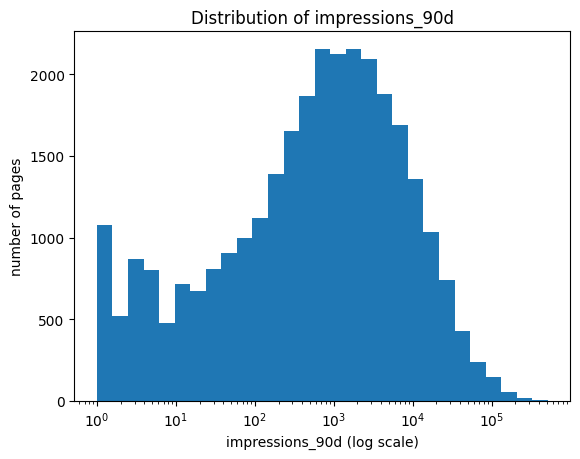

In [52]:
import matplotlib.pyplot as plt
print(df['impressions_90d'].describe())

plt.hist(df['impressions_90d'], bins=np.logspace(0, np.log10(df['impressions_90d'].max()), 30))
plt.xscale('log')
plt.xlabel('impressions_90d (log scale)')
plt.ylabel('number of pages')
plt.title('Distribution of impressions_90d')
plt.show()


In [74]:
low_range = df[df['impressions_90d'] <= 11]
display(low_range['content_type'].value_counts())
display(df.groupby('content_type')['impressions_90d'].median())

content_type
keyword article       2685
feedly article        1297
comparison article      11
Name: count, dtype: int64

content_type
comparison article    107.0
feedly article          4.0
keyword article       955.0
Name: impressions_90d, dtype: float64

## 4. Careful words: what I can and can't claim

*Write what your work will be able to say (observed, directional, decision-support) — and what it never will (causal proof, 'predicting Google').*

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.